# Notebook 1 – Data Cleaning
## Airbnb Capstone | Madrid vs Tokyo

**Team:** Juan Luis Cadenas ·Abril Balbi · Shirin Aliyeva · Georgi Opnakov · Juan David Rodriguez

### What this notebook does
1. Loads raw data for both cities (`listings`, `calendar`, `reviews`)
2. Cleans each dataset independently per city
3. Engineers features from calendar (seasonality) and reviews (recency/volume)
4. Merges everything into one clean dataset
5. Saves `airbnb_clean_final.csv` to the shared Drive

**Output:** `airbnb_clean_final.csv` → used by all subsequent notebooks

In [1]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Path config ───────────────────────────────────────────────────────────────
DATA_PATH   = "/content/drive/Shareddrives/MBD_Capstone Project_KPMG/1. Data/"
OUTPUT_PATH = DATA_PATH   # save clean file to same folder

JPY_TO_EUR  = 0.0062      # update if needed

In [3]:
# ── Load raw data ─────────────────────────────────────────────────────────────
# All files are .csv.gz (Gzip compressed)
# parse_dates at load time avoids a separate conversion step later

print("Loading listings...")
madrid_listings_raw = pd.read_csv(DATA_PATH + "madrid_listings.csv.gz", compression="gzip")
tokyo_listings_raw  = pd.read_csv(DATA_PATH + "tokyo_listings.csv.gz",  compression="gzip")

print("Loading calendar...")
madrid_calendar_raw = pd.read_csv(DATA_PATH + "madrid_calendar.csv.gz", compression="gzip", parse_dates=["date"])
tokyo_calendar_raw  = pd.read_csv(DATA_PATH + "tokyo_calendar.csv.gz",  compression="gzip", parse_dates=["date"])

print("Loading reviews...")
madrid_reviews_raw  = pd.read_csv(DATA_PATH + "madrid_reviews.csv.gz",  compression="gzip", parse_dates=["date"])
tokyo_reviews_raw   = pd.read_csv(DATA_PATH + "tokyo_reviews.csv.gz",   compression="gzip", parse_dates=["date"])

print("\n── Raw shapes ──────────────────────────")
print(f"Madrid listings:  {madrid_listings_raw.shape}")
print(f"Tokyo listings:   {tokyo_listings_raw.shape}")
print(f"Madrid calendar:  {madrid_calendar_raw.shape}")
print(f"Tokyo calendar:   {tokyo_calendar_raw.shape}")
print(f"Madrid reviews:   {madrid_reviews_raw.shape}")
print(f"Tokyo reviews:    {tokyo_reviews_raw.shape}")

Loading listings...
Loading calendar...
Loading reviews...

── Raw shapes ──────────────────────────
Madrid listings:  (25000, 79)
Tokyo listings:   (27945, 79)
Madrid calendar:  (9125007, 7)
Tokyo calendar:   (10199937, 7)
Madrid reviews:   (215715, 6)
Tokyo reviews:    (1005052, 6)


---
## 1. Listings Cleaning

**Strategy:**
- We keep only columns relevant to price prediction and guest decision-making
- We clean each city independently (different distributions, different currencies)
- We remove outliers using IQR (robust to skewed price distributions)
- We merge cities only after both are fully clean

In [4]:
# ── Column selection ──────────────────────────────────────────────────────────
# Kept:  guest-facing drivers, host-controlled signals, property structure
# Dropped: IDs, URLs, free-text descriptions, redundant sub-scores

COLS_TO_KEEP = [
    "id",                        # join key only – dropped before modelling
    # Location
    "neighbourhood_cleansed", "latitude", "longitude",
    # Property
    "property_type", "room_type", "accommodates",
    "bathrooms_text",            # parsed to numeric below
    "bedrooms", "beds",
    "amenities",                 # converted to count below
    # Host
    "host_is_superhost", "host_response_rate",
    "host_acceptance_rate", "host_response_time",
    "host_listings_count", "instant_bookable",
    # Availability
    "availability_30", "availability_60",
    "availability_90", "availability_365",
    "minimum_nights", "maximum_nights",
    # Reviews
    "number_of_reviews", "number_of_reviews_ltm",
    "review_scores_rating", "review_scores_cleanliness",
    "review_scores_location", "review_scores_value",
    "reviews_per_month",
    # Target variable
    "price",
]

def select_cols(df, cols, city):
    """Keep only relevant columns; warn about any that are missing."""
    existing = [c for c in cols if c in df.columns]
    missing  = [c for c in cols if c not in df.columns]
    if missing:
        print(f"  [{city}] Columns not found (may vary by scrape): {missing}")
    return df[existing].copy()

madrid = select_cols(madrid_listings_raw, COLS_TO_KEEP, "Madrid")
tokyo  = select_cols(tokyo_listings_raw,  COLS_TO_KEEP, "Tokyo")

In [5]:
# ── Listings cleaning function ────────────────────────────────────────────────

def clean_listings(df, city_name, currency="EUR"):
    """
    Full cleaning pipeline for one city's listings.
    Returns a cleaned copy with city label added.
    """
    df = df.copy()
    print(f"\n{'='*55}")
    print(f" Cleaning listings: {city_name}  |  Raw: {df.shape}")
    print(f"{'='*55}")

    df["city"] = city_name

    # 1. Price – strip symbols and convert to numeric
    df["price"] = (
        df["price"].astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
    )
    df["price"] = pd.to_numeric(df["price"], errors="coerce")

    # Currency conversion: Tokyo prices are in JPY
    if currency == "JPY":
        df["price"] = df["price"] * JPY_TO_EUR
        print(f"  ✓ JPY → EUR conversion applied (rate: {JPY_TO_EUR})")

    # Drop missing or zero prices
    before = len(df)
    df = df.dropna(subset=["price"])
    df = df[df["price"] > 0]
    print(f"  ✓ Price nulls/zeros removed: {before - len(df)} rows")

    # 2. Outlier removal – IQR method
    # We use IQR instead of z-score because price is right-skewed (log-normal).
    # z-score assumes normality and would retain extreme luxury outliers.
    # See Annex at end of notebook for full justification.
    Q1  = df["price"].quantile(0.25)
    Q3  = df["price"].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df)
    df = df[(df["price"] >= lower) & (df["price"] <= upper)]
    print(f"  ✓ Outliers removed (IQR): {before - len(df)} rows | "
          f"price range kept: [{lower:.1f} – {upper:.1f}] EUR")

    # 3. Bathrooms – parse text to numeric
    # e.g. "1 bath", "1.5 baths", "Shared half-bath" → float
    if "bathrooms_text" in df.columns:
        df["bathrooms"] = (
            df["bathrooms_text"].astype(str)
            .str.extract(r"(\d+\.?\d*)")
            .astype(float)
        )
        df.drop(columns=["bathrooms_text"], inplace=True)

    # 4. Amenities – convert JSON-like string to count
    # Raw format: '{"Wifi","Kitchen","TV",...}'
    if "amenities" in df.columns:
        df["amenities_count"] = (
            df["amenities"].astype(str)
            .apply(lambda x: len(x.split(",")))
        )
        df.drop(columns=["amenities"], inplace=True)

    # 5. Boolean columns → 0/1
    for col in ["host_is_superhost", "instant_bookable"]:
        if col in df.columns:
            df[col] = df[col].map({"t": 1, "f": 0, True: 1, False: 0})

    # 6. Rate columns – remove % and convert to 0–1 float
    for col in ["host_response_rate", "host_acceptance_rate"]:
        if col in df.columns:
            df[col] = (
                df[col].astype(str)
                .str.replace("%", "", regex=False).str.strip()
            )
            df[col] = pd.to_numeric(df[col], errors="coerce") / 100

    # 7. Cap minimum_nights – values above 30 are edge cases, not typical rentals
    if "minimum_nights" in df.columns:
        df["minimum_nights"] = df["minimum_nights"].clip(upper=30)

    # 8. Null summary
    null_pct = (df.isnull().sum() / len(df) * 100).round(1)
    null_pct = null_pct[null_pct > 0].sort_values(ascending=False)
    print(f"\n  Remaining nulls:")
    print(null_pct.to_string() if len(null_pct) > 0 else "  None!")
    print(f"\n  ✓ Clean shape: {df.shape}")
    return df


madrid_clean = clean_listings(madrid, "Madrid", currency="EUR")
tokyo_clean  = clean_listings(tokyo,  "Tokyo",  currency="JPY")


 Cleaning listings: Madrid  |  Raw: (25000, 31)
  ✓ Price nulls/zeros removed: 6047 rows
  ✓ Outliers removed (IQR): 1183 rows | price range kept: [-71.0 – 305.0] EUR

  Remaining nulls:
reviews_per_month           15.90
review_scores_location      15.90
review_scores_value         15.90
review_scores_rating        15.90
review_scores_cleanliness   15.90
host_response_rate           5.50
host_response_time           5.50
host_acceptance_rate         3.10
host_is_superhost            2.90
bathrooms                    1.40
host_listings_count          0.50
bedrooms                     0.20
beds                         0.10

  ✓ Clean shape: (17770, 32)

 Cleaning listings: Tokyo  |  Raw: (27945, 31)
  ✓ JPY → EUR conversion applied (rate: 0.0062)
  ✓ Price nulls/zeros removed: 2465 rows
  ✓ Outliers removed (IQR): 1715 rows | price range kept: [-59.3 – 284.0] EUR

  Remaining nulls:
review_scores_rating        13.10
review_scores_cleanliness   13.10
reviews_per_month           13.10
rev

In [6]:
# ── Impute remaining nulls ────────────────────────────────────────────────────
# Numeric cols with <30% nulls  → city median (not global, to avoid mixing)
# Numeric cols with >30% nulls  → drop column
# Categorical cols              → fill with 'Unknown'

def impute_nulls(df, city_name):
    df = df.copy()
    print(f"\n  Imputing nulls: {city_name}")
    for col in df.select_dtypes(include=[np.number]).columns:
        null_pct = df[col].isnull().mean()
        if 0 < null_pct <= 0.30:
            df[col] = df[col].fillna(df[col].median())
        elif null_pct > 0.30:
            print(f"    Dropped (>{30}% null): {col} ({null_pct:.0%})")
            df.drop(columns=[col], inplace=True)
    for col in df.select_dtypes(include=["object"]).columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna("Unknown")
    print(f"    Remaining nulls: {df.isnull().sum().sum()}")
    return df

madrid_clean = impute_nulls(madrid_clean, "Madrid")
tokyo_clean  = impute_nulls(tokyo_clean,  "Tokyo")


  Imputing nulls: Madrid
    Remaining nulls: 0

  Imputing nulls: Tokyo
    Remaining nulls: 0


In [7]:
# ── Merge cities ──────────────────────────────────────────────────────────────
# Merge AFTER cleaning so city distributions are treated independently

listings = pd.concat([madrid_clean, tokyo_clean], ignore_index=True)
print("Combined listings shape:", listings.shape)
print(listings["city"].value_counts())

Combined listings shape: (41535, 32)
city
Tokyo     23765
Madrid    17770
Name: count, dtype: int64


---
## 2. Calendar Cleaning + Seasonality Features

**Why calendar data?**  
The `listings.csv` price is a static snapshot. `calendar.csv` has daily prices and availability for each listing over 365 days.

**Note on date parsing:** dates were already parsed at load time via `parse_dates=["date"]`, so no conversion needed here.

In [8]:
# ── Calendar cleaning function ────────────────────────────────────────────────

def clean_calendar(df, city_name, currency="EUR"):
    df = df.copy()
    print(f"\n{'='*55}")
    print(f" Cleaning calendar: {city_name}  |  Raw: {df.shape}")
    print(f"{'='*55}")

    df["city"] = city_name

    # Date already parsed – just drop any nulls
    df = df.dropna(subset=["date"])

    # 1. Time features
    df["month"]      = df["date"].dt.month
    df["year"]       = df["date"].dt.year
    df["weekday"]    = df["date"].dt.dayofweek   # 0=Mon, 6=Sun
    df["is_weekend"] = (df["weekday"] >= 5).astype(int)

    # 2. Season (Northern Hemisphere – valid for both Madrid and Tokyo)
    season_map = {
        12: "Winter", 1: "Winter",  2: "Winter",
        3:  "Spring", 4: "Spring",  5: "Spring",
        6:  "Summer", 7: "Summer",  8: "Summer",
        9:  "Autumn", 10: "Autumn", 11: "Autumn",
    }
    df["season"]  = df["month"].map(season_map)
    df["quarter"] = df["date"].dt.quarter

    # 3. Availability flag
    df["is_available"] = df["available"].map({"t": 1, "f": 0})

    # 4. Drop raw columns – no price data available in these files
    df.drop(columns=["available", "price", "adjusted_price"], inplace=True)

    print(f"  Available days:   {df['is_available'].sum():,.0f}")
    print(f"  Unavailable days: {(df['is_available'] == 0).sum():,.0f}")
    print(f"  ✓ Clean shape: {df.shape}")
    return df


madrid_cal = clean_calendar(madrid_calendar_raw, "Madrid", currency="EUR")
tokyo_cal  = clean_calendar(tokyo_calendar_raw,  "Tokyo",  currency="JPY")


 Cleaning calendar: Madrid  |  Raw: (9125007, 7)
  Available days:   4,242,647
  Unavailable days: 4,882,360
  ✓ Clean shape: (9125007, 12)

 Cleaning calendar: Tokyo  |  Raw: (10199937, 7)
  Available days:   4,761,531
  Unavailable days: 5,438,406
  ✓ Clean shape: (10199937, 12)


In [9]:
import pandas as pd
import numpy as np

# ── Seasonality features per listing ─────────────────────────────────────────

def make_seasonal_features(df):
    # A. Quarterly occupancy rate
    quarterly_occ = (
        df.groupby(["listing_id", "quarter"])["is_available"]
        .apply(lambda x: 1 - x.mean())
        .unstack(level="quarter", fill_value=np.nan)
        .rename(columns=lambda q: f"occupancy_q{int(q)}")
        .reset_index()
    )

    # B. Seasonal occupancy rate
    seasonal_occ = (
        df.groupby(["listing_id", "season"])["is_available"]
        .apply(lambda x: 1 - x.mean())
        .unstack(level="season", fill_value=np.nan)
        .rename(columns=lambda s: f"occupancy_{s.lower()}")
        .reset_index()
    )

    # C. Overall occupancy rate
    occupancy = (
        df.groupby("listing_id")["is_available"]
        .apply(lambda x: 1 - x.mean())
        .reset_index()
        .rename(columns={"is_available": "occupancy_rate"})
    )

    # D. Weekend vs weekday occupancy
    wknd_occ = (
        df.groupby(["listing_id", "is_weekend"])["is_available"]
        .apply(lambda x: 1 - x.mean())
        .unstack(level="is_weekend", fill_value=np.nan)
        .rename(columns={0: "occupancy_weekday", 1: "occupancy_weekend"})
        .reset_index()
    )

    # Merge all together
    features = quarterly_occ
    for other in [seasonal_occ, occupancy, wknd_occ]:
        features = features.merge(other, on="listing_id", how="left")

    return features


madrid_cal_features = make_seasonal_features(madrid_cal)
tokyo_cal_features  = make_seasonal_features(tokyo_cal)

print("Madrid calendar features:", madrid_cal_features.shape)
print("Tokyo calendar features: ", tokyo_cal_features.shape)
madrid_cal_features.head(3)

Madrid calendar features: (25000, 12)
Tokyo calendar features:  (27945, 12)


,listing_id,occupancy_q1,occupancy_q2,occupancy_q3,occupancy_q4,occupancy_autumn,occupancy_spring,occupancy_summer,occupancy_winter,occupancy_rate,occupancy_weekday,occupancy_weekend
0,21853,0.66,0.00,0.17,1.00,0.85,0.00,0.00,1.00,0.46,0.46,0.45
1,30320,0.03,0.00,0.15,0.07,0.15,0.00,0.00,0.10,0.06,0.06,0.07
2,30959,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


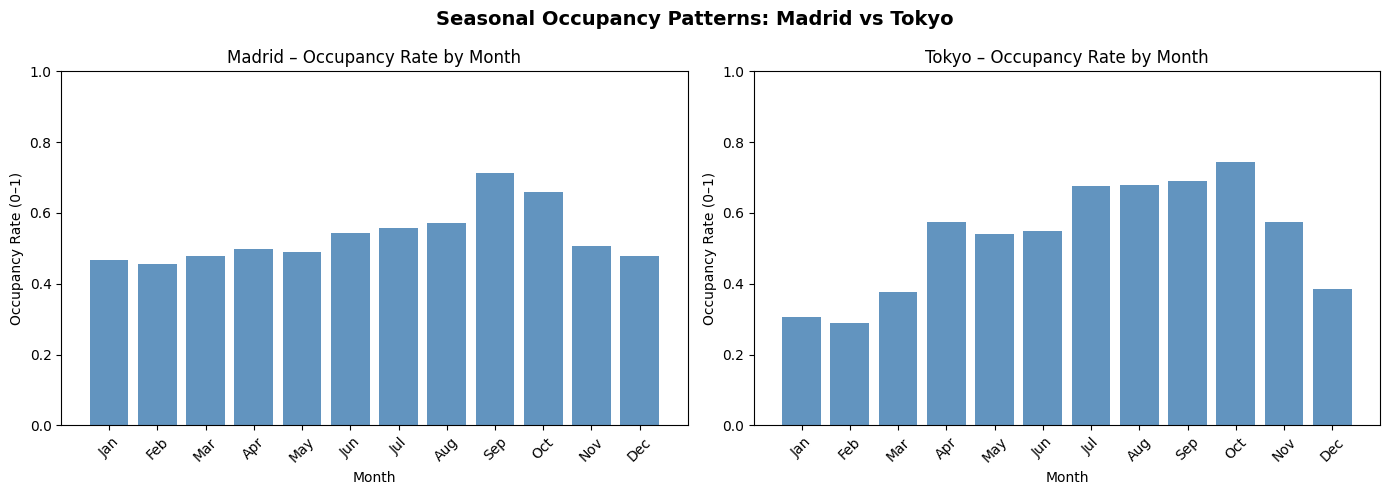

In [10]:
# ── Seasonality quick-check plot ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

for ax, (cal_df, city) in zip(axes, [
    (madrid_cal, "Madrid"),
    (tokyo_cal,  "Tokyo")
]):
    monthly_occ = (
        cal_df.groupby("month")["is_available"]
        .apply(lambda x: 1 - x.mean())
    )
    ax.bar(monthly_occ.index, monthly_occ.values, color="steelblue", alpha=0.85)
    ax.set_title(f"{city} – Occupancy Rate by Month")
    ax.set_xlabel("Month")
    ax.set_ylabel("Occupancy Rate (0–1)")
    ax.set_ylim(0, 1)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, rotation=45)

plt.suptitle("Seasonal Occupancy Patterns: Madrid vs Tokyo", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3. Reviews Cleaning + Activity Features


- Recent review activity → proxy for current demand
- Listing age → proxy for established reputation
- Reviews in last 6 months → captures momentum

**Note:** we don't use the text of comments here. Here we only use dates for activity features.

**Note on date parsing:** already handled at load time.

In [11]:
# ── Reviews cleaning function ─────────────────────────────────────────────────

def clean_reviews(df, city_name):
    df = df.copy()
    print(f"\n{'='*55}")
    print(f" Cleaning reviews: {city_name}  |  Raw: {df.shape}")
    print(f"{'='*55}")

    df["city"] = city_name

    # Date already parsed – drop nulls
    df = df.dropna(subset=["date"])

    # Drop PII columns (reviewer name, reviewer id) – no analytical value
    pii_cols = ["reviewer_name", "reviewer_id", "id"]
    df.drop(columns=[c for c in pii_cols if c in df.columns], inplace=True)

    # Drop empty comments
    if "comments" in df.columns:
        df = df[df["comments"].notna() & (df["comments"].str.strip() != "")]

    print(f"  ✓ Clean shape: {df.shape}")
    return df


madrid_rev = clean_reviews(madrid_reviews_raw, "Madrid")
tokyo_rev  = clean_reviews(tokyo_reviews_raw,  "Tokyo")


 Cleaning reviews: Madrid  |  Raw: (215715, 6)
  ✓ Clean shape: (215658, 4)

 Cleaning reviews: Tokyo  |  Raw: (1005052, 6)
  ✓ Clean shape: (1004918, 4)


In [12]:
# ── Review activity features per listing ──────────────────────────────────────

REFERENCE_DATE = pd.Timestamp("today").normalize()
RECENT_MONTHS  = 6

def make_review_features(df):
    recent_cutoff = REFERENCE_DATE - pd.DateOffset(months=RECENT_MONTHS)

    # Base aggregation
    agg = df.groupby("listing_id").agg(
        total_reviews     = ("date", "count"),
        first_review_date = ("date", "min"),
        last_review_date  = ("date", "max"),
    ).reset_index()

    # Days since last review (recency signal)
    agg["days_since_last_review"] = (
        REFERENCE_DATE - agg["last_review_date"]
    ).dt.days

    # Listing age in days
    agg["listing_age_days"] = (
        REFERENCE_DATE - agg["first_review_date"]
    ).dt.days

    # Reviews in last 6 months (demand momentum)
    recent = (
        df[df["date"] >= recent_cutoff]
        .groupby("listing_id")["date"]
        .count()
        .reset_index()
        .rename(columns={"date": f"reviews_last_{RECENT_MONTHS}m"})
    )
    agg = agg.merge(recent, on="listing_id", how="left")
    agg[f"reviews_last_{RECENT_MONTHS}m"] = (
        agg[f"reviews_last_{RECENT_MONTHS}m"].fillna(0).astype(int)
    )

    agg.drop(columns=["first_review_date", "last_review_date"], inplace=True)
    return agg


madrid_rev_features = make_review_features(madrid_rev)
tokyo_rev_features  = make_review_features(tokyo_rev)

print("Madrid review features:", madrid_rev_features.shape)
print("Tokyo review features: ", tokyo_rev_features.shape)
madrid_rev_features.head(3)

Madrid review features: (2884, 5)
Tokyo review features:  (24009, 5)


,listing_id,total_reviews,days_since_last_review,listing_age_days,reviews_last_6m
0,3781,27,215,3950,0
1,5506,140,147,6252,2
2,6695,143,155,6114,2


---
## 4. Final Merge

Join listings + calendar features + review features on `listing_id`  
→ One clean row per listing, ready for EDA and modelling

In [13]:
# ── Combine features across cities then join ──────────────────────────────────

cal_features = pd.concat([madrid_cal_features, tokyo_cal_features], ignore_index=True)
rev_features = pd.concat([madrid_rev_features, tokyo_rev_features], ignore_index=True)

# Join calendar features
df_final = listings.merge(
    cal_features,
    left_on="id", right_on="listing_id", how="left"
).drop(columns=["listing_id"])

# Join review features
df_final = df_final.merge(
    rev_features,
    left_on="id", right_on="listing_id", how="left"
).drop(columns=["listing_id"])

# Drop id column (not a model feature)
df_final.drop(columns=["id"], inplace=True)

print("✓ Final dataset shape:", df_final.shape)
print(df_final["city"].value_counts())

✓ Final dataset shape: (41535, 46)
city
Tokyo     23765
Madrid    17770
Name: count, dtype: int64


In [14]:
# ── Fill nulls introduced by the joins ───────────────────────────────────────
# Listings with no calendar/review data get NaN for those features
# Fill with city-level medians so we don't mix Tokyo and Madrid values

cal_cols = [c for c in df_final.columns
            if c.startswith("avg_price") or
            c in ["occupancy_rate", "weekend_premium",
                  "avg_price_weekday", "avg_price_weekend"]]

df_final[cal_cols] = df_final.groupby("city")[cal_cols].transform("median")

# Final null check
null_summary = (df_final.isnull().sum() / len(df_final) * 100).round(1)
null_summary = null_summary[null_summary > 0].sort_values(ascending=False)
print("Remaining nulls (%) after join fill:")
print(null_summary if len(null_summary) > 0 else "None!")

Remaining nulls (%) after join fill:
total_reviews            50.30
days_since_last_review   50.30
listing_age_days         50.30
reviews_last_6m          50.30
dtype: float64


In [15]:
# ── Final overview ────────────────────────────────────────────────────────────

print("\n── Dataset summary ──────────────────────")
print(f"Shape:   {df_final.shape}")
print(f"Cities:  {df_final['city'].value_counts().to_dict()}")
print(f"Columns: {list(df_final.columns)}")
print("\nPrice stats by city:")
print(df_final.groupby("city")["price"].describe().round(2))


── Dataset summary ──────────────────────
Shape:   (41535, 46)
Cities:  {'Tokyo': 23765, 'Madrid': 17770}
Columns: ['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'host_response_time', 'host_listings_count', 'instant_bookable', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'price', 'city', 'bathrooms', 'amenities_count', 'occupancy_q1', 'occupancy_q2', 'occupancy_q3', 'occupancy_q4', 'occupancy_autumn', 'occupancy_spring', 'occupancy_summer', 'occupancy_winter', 'occupancy_rate', 'occupancy_weekday', 'occupancy_weekend', 'total_reviews', 'days_since_last_review', 'listing_age_days', 'reviews_last_6m']

Price stats by c

In [16]:
# ── Save to shared Drive ──────────────────────────────────────────────────────
# This file is the input for Notebook 2 (EDA), Notebook 3 (Modelling),
# and Notebook 4 (Chatbot) – do not modify it manually after saving

output_file = OUTPUT_PATH + "airbnb_clean_final.csv"
df_final.to_csv(output_file, index=False)
print(f"✓ Saved: {output_file}")
print(f"  Shape: {df_final.shape}")

✓ Saved: /content/drive/Shareddrives/MBD_Capstone Project_KPMG/1. Data/airbnb_clean_final.csv
  Shape: (41535, 46)
